In [60]:
import numpy as np
import pandas as pd
import seaborn as sns

In [61]:
df=pd.read_csv("Bengaluru_House_Data.csv")
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [63]:
df=df.drop(["area_type","availability","society","balcony"],axis=1)
df.head()

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00


Handling the missing values

In [64]:
df.isnull().sum()

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

In [65]:
df["location"].value_counts()

location
Whitefield                        540
Sarjapur  Road                    399
Electronic City                   302
Kanakpura Road                    273
Thanisandra                       234
                                 ... 
Bapuji Layout                       1
1st Stage Radha Krishna Layout      1
BEML Layout 5th stage               1
singapura paradise                  1
Abshot Layout                       1
Name: count, Length: 1305, dtype: int64

In [66]:
df["location"]=df["location"].fillna("Sarjapur  Road")
df["location"].value_counts()

location
Whitefield                        540
Sarjapur  Road                    400
Electronic City                   302
Kanakpura Road                    273
Thanisandra                       234
                                 ... 
Bapuji Layout                       1
1st Stage Radha Krishna Layout      1
BEML Layout 5th stage               1
singapura paradise                  1
Abshot Layout                       1
Name: count, Length: 1305, dtype: int64

In [67]:
df["size"].value_counts()

size
2 BHK         5199
3 BHK         4310
4 Bedroom      826
4 BHK          591
3 Bedroom      547
1 BHK          538
2 Bedroom      329
5 Bedroom      297
6 Bedroom      191
1 Bedroom      105
8 Bedroom       84
7 Bedroom       83
5 BHK           59
9 Bedroom       46
6 BHK           30
7 BHK           17
1 RK            13
10 Bedroom      12
9 BHK            8
8 BHK            5
11 BHK           2
11 Bedroom       2
10 BHK           2
14 BHK           1
13 BHK           1
12 Bedroom       1
27 BHK           1
43 Bedroom       1
16 BHK           1
19 BHK           1
18 Bedroom       1
Name: count, dtype: int64

In [68]:
df["size"]=df["size"].fillna("2 BHK")
df["size"].value_counts()

size
2 BHK         5215
3 BHK         4310
4 Bedroom      826
4 BHK          591
3 Bedroom      547
1 BHK          538
2 Bedroom      329
5 Bedroom      297
6 Bedroom      191
1 Bedroom      105
8 Bedroom       84
7 Bedroom       83
5 BHK           59
9 Bedroom       46
6 BHK           30
7 BHK           17
1 RK            13
10 Bedroom      12
9 BHK            8
8 BHK            5
11 BHK           2
11 Bedroom       2
10 BHK           2
14 BHK           1
13 BHK           1
12 Bedroom       1
27 BHK           1
43 Bedroom       1
16 BHK           1
19 BHK           1
18 Bedroom       1
Name: count, dtype: int64

In [69]:
df.isnull().sum()

location       0
size           0
total_sqft     0
bath          73
price          0
dtype: int64

In [70]:
df["bath"].value_counts()

bath
2.0     6908
3.0     3286
4.0     1226
1.0      788
5.0      524
6.0      273
7.0      102
8.0       64
9.0       43
10.0      13
12.0       7
13.0       3
11.0       3
16.0       2
27.0       1
40.0       1
15.0       1
14.0       1
18.0       1
Name: count, dtype: int64

In [71]:
med_bath=df["bath"].median()
med_bath

2.0

In [72]:
df["bath"]=df["bath"].fillna(med_bath)


In [73]:
df["bath"].value_counts()

bath
2.0     6981
3.0     3286
4.0     1226
1.0      788
5.0      524
6.0      273
7.0      102
8.0       64
9.0       43
10.0      13
12.0       7
13.0       3
11.0       3
16.0       2
27.0       1
40.0       1
15.0       1
14.0       1
18.0       1
Name: count, dtype: int64

In [74]:
df["bath"]=df["bath"].astype(int)
df["bath"].value_counts()

bath
2     6981
3     3286
4     1226
1      788
5      524
6      273
7      102
8       64
9       43
10      13
12       7
13       3
11       3
16       2
27       1
40       1
15       1
14       1
18       1
Name: count, dtype: int64

In [75]:
df["bath"].unique()

array([ 2,  5,  3,  4,  6,  1,  9,  8,  7, 11, 10, 14, 27, 12, 16, 40, 15,
       13, 18])

In [76]:
df.isnull().sum()

location      0
size          0
total_sqft    0
bath          0
price         0
dtype: int64

In [77]:
#dropping duplicate rows
df.drop_duplicates(inplace=True)

Feature engineering

In [78]:
df

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5,120.00
2,Uttarahalli,3 BHK,1440,2,62.00
3,Lingadheeranahalli,3 BHK,1521,3,95.00
4,Kothanur,2 BHK,1200,2,51.00
...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715,3,112.00
13315,Whitefield,5 Bedroom,3453,4,231.00
13316,Richards Town,4 BHK,3600,5,400.00
13317,Raja Rajeshwari Nagar,2 BHK,1141,2,60.00


In [79]:
#Handling the location column
df["location"].value_counts()

location
Whitefield                        507
Sarjapur  Road                    365
Electronic City                   273
Thanisandra                       224
Kanakpura Road                    223
                                 ... 
1st Stage Radha Krishna Layout      1
BEML Layout 5th stage               1
singapura paradise                  1
Uvce Layout                         1
Abshot Layout                       1
Name: count, Length: 1305, dtype: int64

In [80]:
df["location"].unique()

array(['Electronic City Phase II', 'Chikka Tirupathi', 'Uttarahalli', ...,
       '12th cross srinivas nagar banshankari 3rd stage',
       'Havanur extension', 'Abshot Layout'], dtype=object)

In [81]:
#remove the extra spaces we are triming 
df["location"]=df["location"].apply(lambda x:x.strip())

In [82]:
loc=df["location"].value_counts()
loc_less_than_10=loc[loc<=10]

In [83]:
#if location is rare 9houses are <10 ) then add it to others or else remain same
df["location"]=df["location"].apply(lambda x:"others" if x in loc_less_than_10 else x)
df["location"].value_counts()

location
others                  2927
Whitefield               508
Sarjapur  Road           365
Electronic City          275
Thanisandra              226
                        ... 
Banashankari Stage V      11
Doddakallasandra          11
Kodigehalli               11
NGR Layout                11
LB Shastri Nagar          11
Name: count, Length: 232, dtype: int64

In [84]:
#Handling the size column
out= [int(i.split()[0]) for i in df["size"]]
df["bhk"]=out
df

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056,2,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5,120.00,4
2,Uttarahalli,3 BHK,1440,2,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3,95.00,3
4,Kothanur,2 BHK,1200,2,51.00,2
...,...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715,3,112.00,3
13315,Whitefield,5 Bedroom,3453,4,231.00,5
13316,others,4 BHK,3600,5,400.00,4
13317,Raja Rajeshwari Nagar,2 BHK,1141,2,60.00,2


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12438 entries, 0 to 13318
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    12438 non-null  object 
 1   size        12438 non-null  object 
 2   total_sqft  12438 non-null  object 
 3   bath        12438 non-null  int32  
 4   price       12438 non-null  float64
 5   bhk         12438 non-null  int64  
dtypes: float64(1), int32(1), int64(1), object(3)
memory usage: 631.6+ KB


In [86]:
df

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056,2,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5,120.00,4
2,Uttarahalli,3 BHK,1440,2,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3,95.00,3
4,Kothanur,2 BHK,1200,2,51.00,2
...,...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715,3,112.00,3
13315,Whitefield,5 Bedroom,3453,4,231.00,5
13316,others,4 BHK,3600,5,400.00,4
13317,Raja Rajeshwari Nagar,2 BHK,1141,2,60.00,2


In [87]:
def clean_sqft(sqft):
    l=sqft.split("-")
    if len(l)==2:
        return float(l[0])+float(l[1])/2
    try:
        return float(l[0])
    except:
        return None

df["total_sqft"]=df["total_sqft"].apply(clean_sqft)


In [88]:
df

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056.0,2,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600.0,5,120.00,4
2,Uttarahalli,3 BHK,1440.0,2,62.00,3
3,Lingadheeranahalli,3 BHK,1521.0,3,95.00,3
4,Kothanur,2 BHK,1200.0,2,51.00,2
...,...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715.0,3,112.00,3
13315,Whitefield,5 Bedroom,3453.0,4,231.00,5
13316,others,4 BHK,3600.0,5,400.00,4
13317,Raja Rajeshwari Nagar,2 BHK,1141.0,2,60.00,2


In [89]:
df["total_sqft"]=df["total_sqft"].fillna(round(df["total_sqft"].mean()))

In [90]:
df  

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056.0,2,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600.0,5,120.00,4
2,Uttarahalli,3 BHK,1440.0,2,62.00,3
3,Lingadheeranahalli,3 BHK,1521.0,3,95.00,3
4,Kothanur,2 BHK,1200.0,2,51.00,2
...,...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715.0,3,112.00,3
13315,Whitefield,5 Bedroom,3453.0,4,231.00,5
13316,others,4 BHK,3600.0,5,400.00,4
13317,Raja Rajeshwari Nagar,2 BHK,1141.0,2,60.00,2


In [91]:
df["price_per_sqft"]=df["price"]*100000/df["total_sqft"]
df

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2,51.00,2,4250.000000
...,...,...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715.0,3,112.00,3,6530.612245
13315,Whitefield,5 Bedroom,3453.0,4,231.00,5,6689.834926
13316,others,4 BHK,3600.0,5,400.00,4,11111.111111
13317,Raja Rajeshwari Nagar,2 BHK,1141.0,2,60.00,2,5258.545136


In [92]:
df["total_sqft"].unique()

array([1056., 2600., 1440., ..., 2758.,  774., 4689.])

In [93]:
df["total_sqft"].describe()

count    12438.000000
mean      1589.759552
std       1288.184379
min          1.000000
25%       1100.000000
50%       1296.000000
75%       1700.000000
max      52272.000000
Name: total_sqft, dtype: float64

In [94]:
df=df[df["total_sqft"]/df["bhk"]>=300]
df["total_sqft"].describe()

count    11705.000000
mean      1628.246502
std       1313.481400
min        300.000000
25%       1124.000000
50%       1320.000000
75%       1735.000000
max      52272.000000
Name: total_sqft, dtype: float64

In [95]:
df["bhk"].describe()

count    11705.000000
mean         2.666809
std          0.995743
min          1.000000
25%          2.000000
50%          3.000000
75%          3.000000
max         16.000000
Name: bhk, dtype: float64

In [96]:
df=df[df["bhk"]<=6]

In [97]:
df=df[df["bath"]<df["bhk"]+2]

In [98]:
df

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2,51.00,2,4250.000000
...,...,...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715.0,3,112.00,3,6530.612245
13315,Whitefield,5 Bedroom,3453.0,4,231.00,5,6689.834926
13316,others,4 BHK,3600.0,5,400.00,4,11111.111111
13317,Raja Rajeshwari Nagar,2 BHK,1141.0,2,60.00,2,5258.545136


In [99]:
df["bhk"].describe()

count    11467.000000
mean         2.607831
std          0.855586
min          1.000000
25%          2.000000
50%          3.000000
75%          3.000000
max          6.000000
Name: bhk, dtype: float64

In [100]:
# removing the outliers present in the price_per_sqrt
q1=df["price_per_sqft"].quantile(0.25)
q3=df["price_per_sqft"].quantile(0.75)

In [101]:
IQR=q3-q1
lower=q1-0.5*IQR
upper=q3+0.5*IQR

<Axes: xlabel='price_per_sqft'>

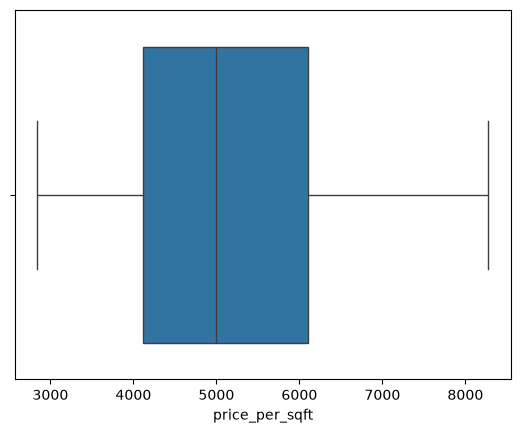

In [102]:
df=df[(df["price_per_sqft"]>=lower)&(df["price_per_sqft"]<=upper)]
sns.boxplot(x="price_per_sqft",data=df)

In [103]:
df.reset_index(inplace=True)

In [104]:
df

,index,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,0,Electronic City Phase II,2 BHK,1056.0,2,39.07,2,3699.810606
1,1,Chikka Tirupathi,4 Bedroom,2600.0,5,120.00,4,4615.384615
2,2,Uttarahalli,3 BHK,1440.0,2,62.00,3,4305.555556
3,3,Lingadheeranahalli,3 BHK,1521.0,3,95.00,3,6245.890861
4,4,Kothanur,2 BHK,1200.0,2,51.00,2,4250.000000
...,...,...,...,...,...,...,...,...
9429,13310,Rachenahalli,2 BHK,1050.0,2,52.71,2,5020.000000
9430,13312,Bellandur,2 BHK,1262.0,2,47.00,2,3724.247227
9431,13314,Green Glen Layout,3 BHK,1715.0,3,112.00,3,6530.612245
9432,13315,Whitefield,5 Bedroom,3453.0,4,231.00,5,6689.834926


In [105]:
df=df.drop(["index","size","price_per_sqft"],axis=1)
df

,location,total_sqft,bath,price,bhk
0,Electronic City Phase II,1056.0,2,39.07,2
1,Chikka Tirupathi,2600.0,5,120.00,4
2,Uttarahalli,1440.0,2,62.00,3
3,Lingadheeranahalli,1521.0,3,95.00,3
4,Kothanur,1200.0,2,51.00,2
...,...,...,...,...,...
9429,Rachenahalli,1050.0,2,52.71,2
9430,Bellandur,1262.0,2,47.00,2
9431,Green Glen Layout,1715.0,3,112.00,3
9432,Whitefield,3453.0,4,231.00,5


Model Training

In [106]:
from sklearn.preprocessing import LabelEncoder,Normalizer,StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import r2_score,mean_absolute_error

In [107]:
encoder=LabelEncoder()
df["encoded_loc"]=encoder.fit_transform(df["location"])
df

,location,total_sqft,bath,price,bhk,encoded_loc
0,Electronic City Phase II,1056.0,2,39.07,2,75
1,Chikka Tirupathi,2600.0,5,120.00,4,57
2,Uttarahalli,1440.0,2,62.00,3,216
3,Lingadheeranahalli,1521.0,3,95.00,3,154
4,Kothanur,1200.0,2,51.00,2,146
...,...,...,...,...,...,...
9429,Rachenahalli,1050.0,2,52.71,2,183
9430,Bellandur,1262.0,2,47.00,2,40
9431,Green Glen Layout,1715.0,3,112.00,3,83
9432,Whitefield,3453.0,4,231.00,5,224


In [108]:
X=df.drop(["location","price"],axis=1)
y=df.price
X

,total_sqft,bath,bhk,encoded_loc
0,1056.0,2,2,75
1,2600.0,5,4,57
2,1440.0,2,3,216
3,1521.0,3,3,154
4,1200.0,2,2,146
...,...,...,...,...
9429,1050.0,2,2,183
9430,1262.0,2,2,40
9431,1715.0,3,3,83
9432,3453.0,4,5,224


In [109]:
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,test_size=0.3,random_state=42)

In [110]:
model=RandomForestRegressor(random_state=42)

In [111]:
params={
    "n_estimators":[100,150,200,250,300],
    "max_depth":[3,4,5,6,7]
}

In [112]:
grid=GridSearchCV(estimator=model,param_grid=params,cv=5)
grid.fit(Xtrain,ytrain)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 4, ...], 'n_estimators': [100, 150, ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information

In [113]:
print("Best params: ",grid.best_params_)
print("Best score",grid.best_score_)

Best params:  {'max_depth': 6, 'n_estimators': 100}
Best score 0.837890124599261


In [114]:
ypred=grid.predict(Xtest)
ypred

array([81.70811547, 62.48712229, 52.0802134 , ..., 87.74631532,
       87.5174548 , 46.21219355])

In [115]:
print("Training Efficiency: ",grid.score(Xtrain,ytrain))
print("Testing Efficiency: ",grid.score(Xtest,ytest))

Training Efficiency:  0.8904543025268997
Testing Efficiency:  0.8097544693950254


In [116]:
df.to_csv("cleaned_df.csv")

In [117]:
import joblib
with open("Rf_model.joblib","wb") as file:
    joblib.dump(grid,file)